# Notebook 6 —  Fine-Tuning de Transformer (BETO)

S3e hizo uso de un Transformer pre-entrenado en español (**BETO**, de la Universidad de Chile) y realiza un fine-tuning de la última capa del modelo para la tarea de clasificación de sentimiento sobre el dataset de reseñas de hoteles andaluces (**Andalusian Hotels Reviews**).

## 1. Setup y Detección de Entorno


In [1]:
# Detección de Google Colab e instalación de dependencias
import sys
is_colab = 'google.colab' in sys.modules

if is_colab:
    print("💻 Ejecutando en Google Colab. Instalando dependencias de Hugging Face...")
    !pip install -q transformers datasets accelerate scikit-learn pandas numpy matplotlib seaborn
else:
    print("💻 Ejecutando en entorno local.")

💻 Ejecutando en entorno local.


In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, TrainerCallback
from transformers import EarlyStoppingCallback

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Configurar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Dispositivo de entrenamiento: {device}")

c:\Users\User\DL_Proyecto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔥 Dispositivo de entrenamiento: cuda


## 2. Configuración de Directorios y Carga de Datos

Configuramos las rutas para cargar los datos preprocesados (`dataset_clean.csv`) de ambos datasets:
- `balanced_ahr`: Dataset balanceado.
- `big_ahr`: Dataset desbalanceado original.

In [3]:
BASE_DIR = "results"
DIRS = {k: os.path.join(BASE_DIR, k) for k in ["data", "figures", "models", "metrics"]}

# En Google Colab, si los datos no están en el directorio results, se puede pedir al usuario subir los archivos
if is_colab:
    # Crear carpetas si no existen
    for d in DIRS.values():
        os.makedirs(d, exist_ok=True)
    
    # Si no existen los archivos, pedimos subirlos
    if not os.path.exists(os.path.join(DIRS["data"], "balanced_ahr", "dataset_clean.csv")):
        print("⚠️ No se encontraron los datos preprocesados localmente.")
        print("Suba por favor 'dataset_clean.csv' de 'balanced_ahr' y 'big_ahr'...")
        from google.colab import files
        uploaded = files.upload()
        # El usuario sube los archivos y los movemos a la ruta adecuada
        # Por ahora creamos la estructura para que los mueva manualmente si lo prefiere

### Función de Carga y Split de Datos

Para asegurar que la comparación sea estrictamente justa, aplicamos el **mismo seed (42)** y la **misma estratificación** en `train_test_split` sobre el texto limpio raw, replicando de forma exacta los splits utilizados por los modelos clásicos.

In [4]:
def load_and_split_dataset(dataset_name):
        # Map 'balanced' to 'balanced_ahr'
    dir_name = "balanced_ahr" if dataset_name == "balanced" else dataset_name
    csv_path = os.path.join(DIRS["data"], dir_name, "dataset_clean.csv")
    if not os.path.exists(csv_path):
        # Intento de ruta de respaldo por si se subió a la raíz en Colab
        csv_path = "dataset_clean.csv" if os.path.exists("dataset_clean.csv") else csv_path
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"❌ No se encontró el archivo de datos en: {csv_path}")
            
    df = pd.read_csv(csv_path)
    
    # Separar en textos y etiquetas
    texts = df['text_clean'].astype(str).tolist()
    labels = df['label_bin'].astype(int).tolist()
    
    # Split 80% train, 10% val, 10% test (con la misma lógica que 01_EDA_Preprocessing)
    train_texts, val_test_texts, train_labels, val_test_labels = train_test_split(
        texts, labels, test_size=0.2, random_state=42, stratify=labels
    )
    val_texts, test_texts, val_labels, test_labels = train_test_split(
        val_test_texts, val_test_labels, test_size=0.5, random_state=42, stratify=val_test_labels
    )
    
    print(f"📦 Dataset: {dataset_name}")
    print(f"  Train samples: {len(train_texts):,}")
    print(f"  Val samples  : {len(val_texts):,}")
    print(f"  Test samples : {len(test_texts):,}")
    return train_texts, val_texts, test_texts, train_labels, val_labels, test_labels

## 3. Tokenización del Transformer

Cargamos el tokenizador pre-entrenado de **BETO** y preparamos las secuencias con un límite de palabras (p. ej., `max_length=150` para que coincida con el `max_len` de los modelos clásicos).

In [5]:
MODEL_NAME = "dccuchile/bert-base-spanish-wwm-uncased"  # BETO
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class HotelReviewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

def prepare_torch_datasets(train_texts, val_texts, test_texts, train_labels, val_labels, test_labels, max_len=150):
    train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=max_len)
    val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=max_len)
    test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=max_len)

    train_dataset = HotelReviewsDataset(train_encodings, train_labels)
    val_dataset = HotelReviewsDataset(val_encodings, val_labels)
    test_dataset = HotelReviewsDataset(test_encodings, test_labels)
    
    return train_dataset, val_dataset, test_dataset

## 4. Construcción del Modelo y Fine-Tuning Parcial (Freeze)

Cargamos el modelo pre-entrenado BETO para clasificación de secuencias binarias (2 clases). 

1. Congelamos todos los parámetros del modelo base BERT.
2. Descongelamos la **última capa del codificador transformer** (capa 11 en BERT-base, indexada como `layer[-1]`).
3. Descongelamos el **clasificador final** (capa Dense fully connected añadida sobre BERT).

In [6]:
def build_model():
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    
    # 1. Congelar todo el modelo base
    for param in model.bert.parameters():
        param.requires_grad = False
        
    # 2. Descongelar la última capa encoder de BERT (capa 11)
    for param in model.bert.encoder.layer[-1].parameters():
        param.requires_grad = True
        
    # 3. Asegurar que el clasificador final esté descongelado
    for param in model.classifier.parameters():
        param.requires_grad = True
        
    # Contar parámetros entrenables vs totales
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"🤖 Parámetros Totales: {total_params:,}")
    print(f"🔥 Parámetros Entrenables (Fine-Tuning Parcial): {trainable_params:,} ({trainable_params/total_params*100:.2f}% del modelo)")
    
    return model

## 5. Entrenamiento y Métricas de Evaluación

Definimos la función para calcular las métricas durante la evaluación, utilizando la misma lógica de los modelos clásicos (Accuracy, Precision, Recall, F1-Score, ROC-AUC).

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Aplicar softmax para obtener probabilidades
    probs = np.exp(logits) / np.sum(np.exp(logits), axis=-1, keepdims=True)
    pos_probs = probs[:, 1]  # Probabilidad de clase 1 (Positivo)
    preds = np.argmax(logits, axis=-1)
    
    return {
        "accuracy": float(accuracy_score(labels, preds)),
        "precision": float(precision_score(labels, preds, zero_division=0)),
        "recall": float(recall_score(labels, preds, zero_division=0)),
        "f1": float(f1_score(labels, preds, zero_division=0)),
        "roc_auc": float(roc_auc_score(labels, pos_probs))
    }

### Entrenamiento para ambos datasets (Balanced y Big AHR)

In [8]:
DATASET_NAMES = ["balanced", "big_ahr"]
transformer_results = []
evaluation_plots_data = {}

for ds_name in DATASET_NAMES:
    print(f"\n{'='*60}\n  ENTRENAMIENTO SOBRE: {ds_name.upper()}\n{'='*60}")
    
    # Cargar y split
    train_texts, val_texts, test_texts, train_labels, val_labels, test_labels = load_and_split_dataset(ds_name)
    
    # Convertir a Datasets de PyTorch
    train_dataset, val_dataset, test_dataset = prepare_torch_datasets(
        train_texts, val_texts, test_texts, train_labels, val_labels, test_labels
    )
    
    # Construir modelo y mover al dispositivo
    model = build_model().to(device)
    
    # Configurar argumentos de entrenamiento
    # En CPU reducimos épocas y aumentamos batch para no demorar horas; en GPU usamos hiperparámetros óptimos
    epochs = 4 if torch.cuda.is_available() else 2
    batch_size = 16 if torch.cuda.is_available() else 8
    
    training_args = TrainingArguments(
        output_dir=f"./results/transformer_checkpoints_{ds_name}",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        warmup_ratio=0.1,
        weight_decay=0.01,
        logging_dir='./logs',
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=3e-5,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        report_to="none",
        disable_tqdm=False
    )
    
    # Callback de Early Stopping
    early_stopping = EarlyStoppingCallback(early_stopping_patience=2)
    
    # Inicializar Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[early_stopping]
    )
    
    # Entrenar
    train_result = trainer.train()
    
    # Guardar historial para gráficos
    history = trainer.state.log_history
    
    # Evaluar sobre conjunto de test
    print(f"\n🔍 Evaluando en Test para {ds_name}...")
    predictions_output = trainer.predict(test_dataset)
    test_metrics = predictions_output.metrics
    
    # Calcular predicciones
    logits = predictions_output.predictions
    probs = np.exp(logits) / np.sum(np.exp(logits), axis=-1, keepdims=True)
    y_prob = probs[:, 1]
    y_pred = np.argmax(logits, axis=-1)
    y_te = test_labels
    
    # Imprimir métricas
    print(f"\n  [Transformer_BETO_{ds_name}]")
    print(f"    accuracy    : {test_metrics['test_accuracy']:.4f}")
    print(f"    precision   : {test_metrics['test_precision']:.4f}")
    print(f"    recall      : {test_metrics['test_recall']:.4f}")
    print(f"    f1          : {test_metrics['test_f1']:.4f}")
    print(f"    roc_auc     : {test_metrics['test_roc_auc']:.4f}")
    
    # Guardar resultados estructurados para reporte y tablas
    transformer_results.append({
        "config": "Transformer_BETO",
        "dataset": ds_name,
        "description": "Fine-tuning parcial de BETO (BERT-ES)",
        "params": sum(p.numel() for p in model.parameters() if p.requires_grad),
        "metrics": {
            "accuracy": test_metrics['test_accuracy'],
            "precision": test_metrics['test_precision'],
            "recall": test_metrics['test_recall'],
            "f1": test_metrics['test_f1'],
            "roc_auc": test_metrics['test_roc_auc']
        },
        "history": history
    })
    
    # Guardar datos para gráficos
    evaluation_plots_data[ds_name] = {
        "y_te": y_te,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "history": history
    }
    
    # Guardar el modelo en la carpeta models
    model_save_path = os.path.join(DIRS["models"], f"Transformer_BETO_{ds_name}")
    trainer.save_model(model_save_path)
    print(f"✅ Modelo guardado en {model_save_path}")


  ENTRENAMIENTO SOBRE: BALANCED
📦 Dataset: balanced
  Train samples: 2,688
  Val samples  : 336
  Test samples : 337


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 17105.43it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from diffe

🤖 Parámetros Totales: 109,852,418
🔥 Parámetros Entrenables (Fine-Tuning Parcial): 7,089,410 (6.45% del modelo)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.191388,0.197320,0.925595,0.873239,0.946565,0.908425,0.980786
2,0.109657,0.136917,0.946429,0.895105,0.977099,0.934307,0.992702
3,0.100238,0.124689,0.946429,0.895105,0.977099,0.934307,0.994526
4,0.095742,0.122325,0.949405,0.901408,0.977099,0.937729,0.994712


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.47it/s]



🔍 Evaluando en Test para big_ahr...



  [Transformer_BETO_big_ahr]
    accuracy    : 0.9577
    precision   : 0.9641
    recall      : 0.9853
    f1          : 0.9746
    roc_auc     : 0.9817


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.61it/s]

✅ Modelo guardado en results\models\Transformer_BETO_big_ahr


## 6. Visualizaciones y Guardado de Resultados

Generamos los gráficos correspondientes a la evolución de pérdida/métrica y las matrices de confusión/curvas ROC.

In [9]:
# Guardar métricas del transformer en JSON
transformer_metrics_path = os.path.join(DIRS["metrics"], "Transformer_results.json")
with open(transformer_metrics_path, "w") as f:
    json.dump(transformer_results, f, indent=2)
print(f"✅ Métricas del Transformer guardadas en {transformer_metrics_path}")

# Guardar tabla resumen en CSV
summary_rows = []
for res in transformer_results:
    summary_rows.append({
        "Modelo": res["config"],
        "Dataset": res["dataset"],
        "Accuracy": res["metrics"]["accuracy"],
        "Precision": res["metrics"]["precision"],
        "Recall": res["metrics"]["recall"],
        "F1-Score": res["metrics"]["f1"],
        "ROC-AUC": res["metrics"]["roc_auc"]
    })
df_transformer_summary = pd.DataFrame(summary_rows)
df_transformer_summary.to_csv(os.path.join(DIRS["metrics"], "Transformer_summary.csv"), index=False)
print(df_transformer_summary)

✅ Métricas del Transformer guardadas en results\metrics\Transformer_results.json
             Modelo   Dataset  Accuracy  Precision    Recall  F1-Score  \
0  Transformer_BETO  balanced  0.955490   0.926471  0.961832  0.943820   
1  Transformer_BETO   big_ahr  0.957722   0.964066  0.985310  0.974572   

    ROC-AUC  
0  0.989624  
1  0.981673  


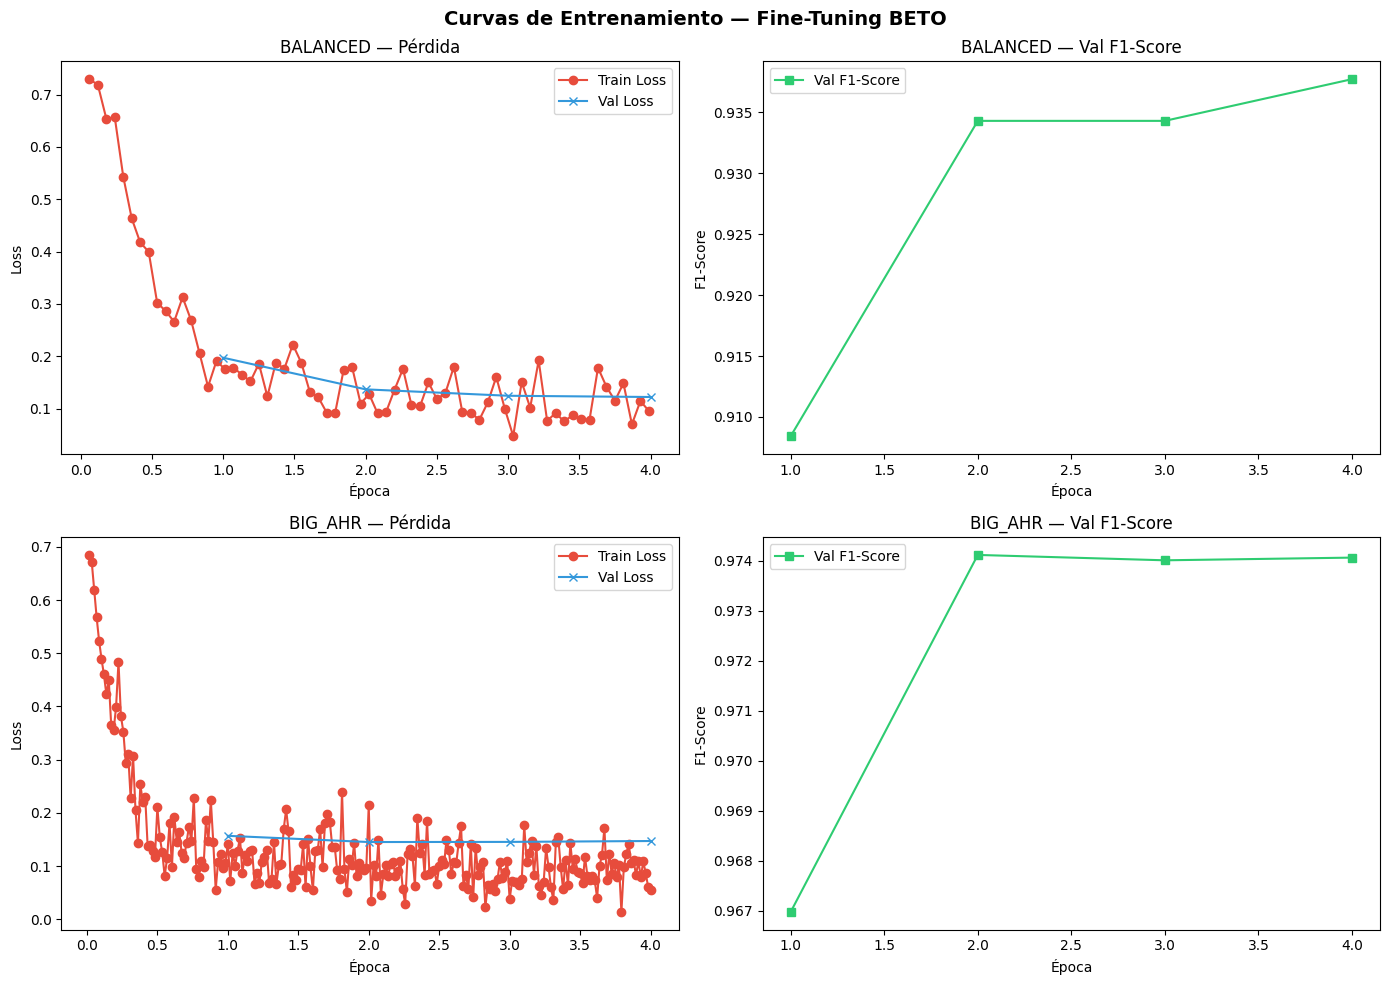

✅ Curvas de entrenamiento guardadas en results\figures\Transformer_training_curves.png


In [10]:
# Gráficas de curvas de entrenamiento
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Curvas de Entrenamiento — Fine-Tuning BETO", fontsize=14, fontweight='bold')

for idx, ds_name in enumerate(DATASET_NAMES):
    hist = evaluation_plots_data[ds_name]["history"]
    
    # Extraer métricas por época
    epochs_metrics = [x for x in hist if 'eval_loss' in x]
    epochs = [x['epoch'] for x in epochs_metrics]
    val_loss = [x['eval_loss'] for x in epochs_metrics]
    val_f1 = [x['eval_f1'] for x in epochs_metrics]
    
    # Para pérdidas de entrenamiento
    train_steps = [x for x in hist if 'loss' in x]
    train_epochs = [x['epoch'] for x in train_steps]
    train_loss = [x['loss'] for x in train_steps]
    
    # Gráfico de Pérdida
    axes[idx][0].plot(train_epochs, train_loss, label='Train Loss', color='#e74c3c', marker='o')
    axes[idx][0].plot(epochs, val_loss, label='Val Loss', color='#3498db', marker='x')
    axes[idx][0].set_title(f"{ds_name.upper()} — Pérdida")
    axes[idx][0].set_xlabel("Época")
    axes[idx][0].set_ylabel("Loss")
    axes[idx][0].legend()
    
    # Gráfico de F1-Score
    axes[idx][1].plot(epochs, val_f1, label='Val F1-Score', color='#2ecc71', marker='s')
    axes[idx][1].set_title(f"{ds_name.upper()} — Val F1-Score")
    axes[idx][1].set_xlabel("Época")
    axes[idx][1].set_ylabel("F1-Score")
    axes[idx][1].legend()

plt.tight_layout()
curves_path = os.path.join(DIRS["figures"], "Transformer_training_curves.png")
plt.savefig(curves_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"✅ Curvas de entrenamiento guardadas en {curves_path}")

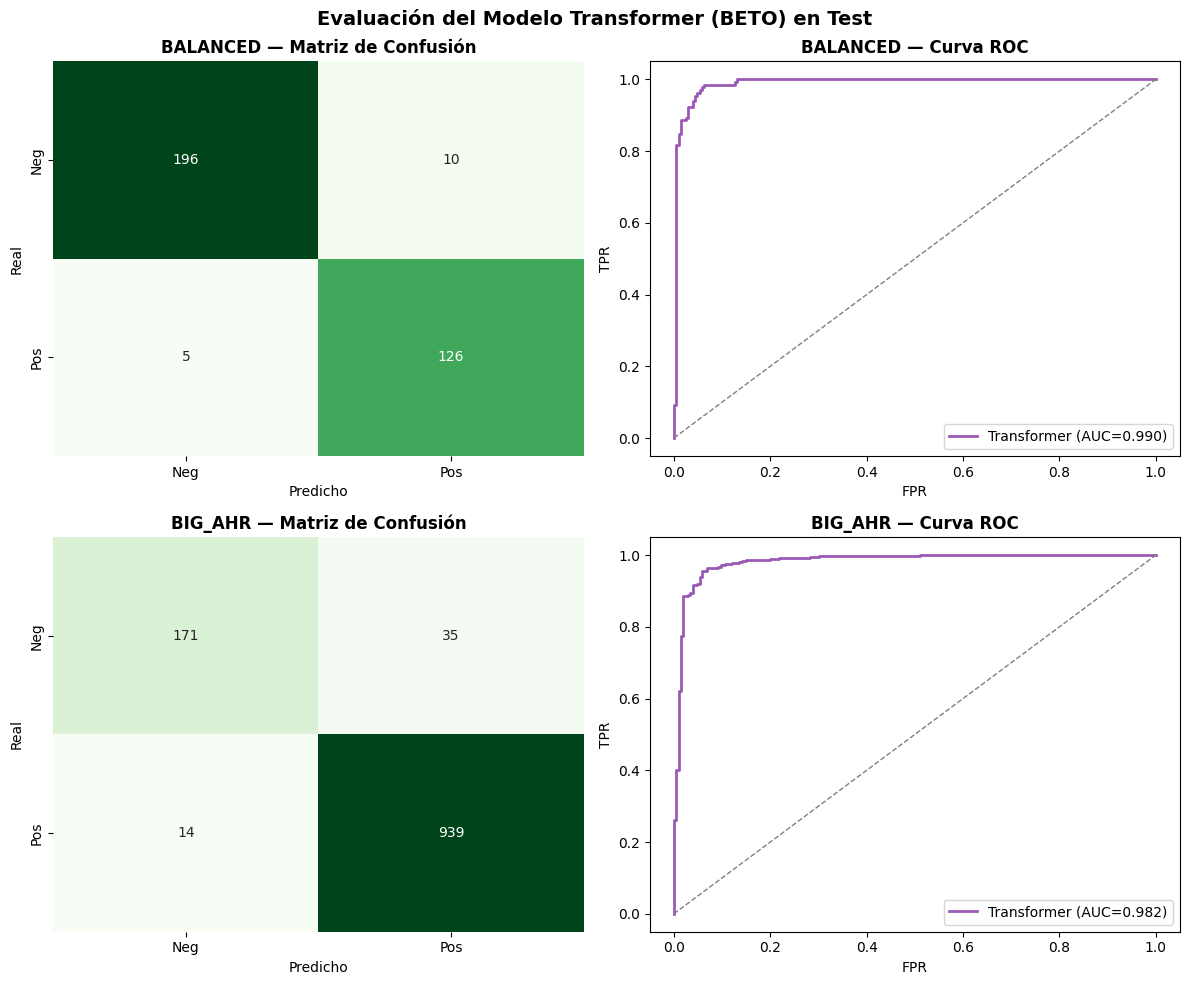

✅ Gráficas de evaluación de test guardadas en results\figures\Transformer_evaluation.png


In [11]:
# Matrices de Confusión y Curvas ROC
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Evaluación del Modelo Transformer (BETO) en Test", fontsize=14, fontweight='bold')

for idx, ds_name in enumerate(DATASET_NAMES):
    plot_data = evaluation_plots_data[ds_name]
    y_te = plot_data["y_te"]
    y_pred = plot_data["y_pred"]
    y_prob = plot_data["y_prob"]
    
    # 1. Matriz de Confusión
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx][0], cmap='Greens', cbar=False,
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
    axes[idx][0].set_title(f"{ds_name.upper()} — Matriz de Confusión", fontweight='bold')
    axes[idx][0].set_xlabel("Predicho")
    axes[idx][0].set_ylabel("Real")
    
    # 2. Curva ROC
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc = roc_auc_score(y_te, y_prob)
    axes[idx][1].plot(fpr, tpr, color='#9b59b6', lw=2, label=f"Transformer (AUC={auc:.3f})")
    axes[idx][1].plot([0,1],[0,1],'--', color='gray', lw=1)
    axes[idx][1].set_title(f"{ds_name.upper()} — Curva ROC", fontweight='bold')
    axes[idx][1].set_xlabel("FPR")
    axes[idx][1].set_ylabel("TPR")
    axes[idx][1].legend(loc='lower right')

plt.tight_layout()
eval_path = os.path.join(DIRS["figures"], "Transformer_evaluation.png")
plt.savefig(eval_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"✅ Gráficas de evaluación de test guardadas en {eval_path}")